# BraTS 2021 (Task 1) — Dataset Setup & EDA


## ⚠️ Scope recheck (BraTS 2021 + BrainIAC only, public-facing model)

This notebook was originally written as part of a wider pipeline that planned to combine BraTS 2021, UCSF-PDGM, Burdenko-GBM-Progression, UPenn-GBM, and GlioCMV/UKER. **If the plan has narrowed to BraTS 2021 + BrainIAC only**, three things change that the EDA below doesn't surface on its own — they're covered in new sections 8–14, appended after the original EDA:

- **No pseudoprogression vs. true-progression classification is possible from BraTS 2021 alone.** Those labels only exist in Burdenko-GBM-Progression. Dropping Burdenko removes the actual novel task (and the Gomaa et al. AUC 0.753 benchmark comparison) — what's left is a *descriptive* glioma Q&A model (location, size, sub-regions), not a progression classifier.
- **BraTS 2021 Task 1 (this Kaggle package) ships no clinical, demographic, or genetic-status data.** Section 1 below already confirms no extra files are bundled inside the archive. Section 11 adds external verification of what exists elsewhere and what doesn't.
- **Both the dataset and BrainIAC carry non-commercial research/education licenses.** "Available for public use" needs a precise definition before deployment — see Section 13.

Sections 8–14 at the end of this notebook work through the preprocessing-compatibility and scope questions this narrower plan raises.

## Step 1 — Install dependencies

In [1]:
# Only what's needed to read NIfTI volumes and do the EDA below.
!pip install -q nibabel tqdm --no-deps

import nibabel as nib
print("nibabel:", nib.__version__)


nibabel: 5.4.2


## Imports

In [2]:
import glob
import os
import tarfile
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
from tqdm import tqdm


## Dataset path

In [3]:
brats_root = "/kaggle/input/datasets/dschettler8845/brats-2021-task1"
brats_extract_dir = "/kaggle/working/brats2021"

print("BraTS root contents:", os.listdir(brats_root)[:5])


BraTS root contents: ['BraTS2021_00495.tar', 'BraTS2021_Training_Data.tar', 'BraTS2021_00621.tar']


## Extract BraTS2021 (packaged as `.tar` archives, ~13.4 GB uncompressed — fits Kaggle scratch disk)

In [4]:
os.makedirs(brats_extract_dir, exist_ok=True)

tar_files = glob.glob(f"{brats_root}/*.tar")
print(f"Found {len(tar_files)} tar files:", [os.path.basename(t) for t in tar_files])

for tar_path in tar_files:
    print(f"Extracting {os.path.basename(tar_path)} ...")
    with tarfile.open(tar_path, "r") as tf:
        for member in tqdm(tf.getmembers(), desc=os.path.basename(tar_path)):
            tf.extract(member, brats_extract_dir)

n_extracted = sum(len(files) for _, _, files in os.walk(brats_extract_dir))
print("Done. Total files extracted:", n_extracted)

total_gb = sum(os.path.getsize(t) for t in tar_files) / 1e9
print(f"{len(tar_files)} tar files, {total_gb:.1f} GB total (compressed/on-disk size)")


Found 3 tar files: ['BraTS2021_00495.tar', 'BraTS2021_Training_Data.tar', 'BraTS2021_00621.tar']
Extracting BraTS2021_00495.tar ...


BraTS2021_00495.tar:   0%|          | 0/6 [00:00<?, ?it/s]/tmp/ipykernel_58/1524565714.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extract(member, brats_extract_dir)
BraTS2021_00495.tar: 100%|██████████| 6/6 [00:00<00:00, 72.50it/s]

Extracting BraTS2021_Training_Data.tar ...



BraTS2021_Training_Data.tar: 100%|██████████| 7508/7508 [01:05<00:00, 113.78it/s]


Extracting BraTS2021_00621.tar ...


BraTS2021_00621.tar: 100%|██████████| 6/6 [00:00<00:00, 107.15it/s]


Done. Total files extracted: 6266
3 tar files, 13.4 GB total (compressed/on-disk size)


## Sanity check — load one sample volume

In [5]:
sample_t1ce = glob.glob(f"{brats_extract_dir}/**/*_t1ce.nii.gz", recursive=True)[0]
img = nib.load(sample_t1ce)
print("Sample file:", sample_t1ce)
print("BraTS T1CE shape/spacing:", img.shape, img.header.get_zooms())


Sample file: /kaggle/working/brats2021/BraTS2021_00495_t1ce.nii.gz
BraTS T1CE shape/spacing: (240, 240, 155) (np.float32(1.0), np.float32(1.0), np.float32(1.0))


## EDA: case discovery & modality completeness

BraTS2021 stores each case as its own folder with up to five files:
`t1`, `t1ce`, `t2`, `flair`, and `seg` (segmentation labels — only present for the
training split, not validation). We discover every case from its `flair` file (present
in every split), then check which of the other modalities exist alongside it.

In [6]:
MODALITIES = ["t1", "t1ce", "t2", "flair", "seg"]

flair_files = sorted(glob.glob(f"{brats_extract_dir}/**/*_flair.nii.gz", recursive=True))
print(f"Found {len(flair_files)} cases (based on *_flair.nii.gz files).")

records = []
for flair_path in flair_files:
    case_dir = os.path.dirname(flair_path)
    case_id = os.path.basename(flair_path).replace("_flair.nii.gz", "")
    row = {"case_id": case_id, "case_dir": case_dir}
    for mod in MODALITIES:
        row[mod] = os.path.exists(os.path.join(case_dir, f"{case_id}_{mod}.nii.gz"))
    records.append(row)

cases_df = pd.DataFrame(records)
print("\nModality completeness (count of cases where the file is present):")
print(cases_df[MODALITIES].sum())

print("\nCases missing any modality:")
incomplete = cases_df[~cases_df[MODALITIES].all(axis=1)]
print(incomplete[["case_id"] + MODALITIES] if len(incomplete) else "None — every case has all 5 files.")

cases_with_seg = cases_df[cases_df["seg"]].reset_index(drop=True)
print(f"\n{len(cases_with_seg)} / {len(cases_df)} cases have a segmentation label (training split).")


Found 1253 cases (based on *_flair.nii.gz files).

Modality completeness (count of cases where the file is present):
t1       1253
t1ce     1253
t2       1253
flair    1253
seg      1253
dtype: int64

Cases missing any modality:
None — every case has all 5 files.

1253 / 1253 cases have a segmentation label (training split).


## EDA: image geometry consistency

Checks the voxel array shape and voxel spacing for every case's T1CE volume (header-only
read via `nibabel`, so this is cheap even across the full dataset) and flags anything that
doesn't match the dataset's expected `(240, 240, 155)` / `1mm` isotropic convention.

In [7]:
shape_counter = Counter()
spacing_counter = Counter()
geometry_outliers = []

for _, row in tqdm(cases_df.iterrows(), total=len(cases_df), desc="Checking geometry"):
    t1ce_path = os.path.join(row["case_dir"], f"{row['case_id']}_t1ce.nii.gz")
    if not os.path.exists(t1ce_path):
        continue
    hdr_img = nib.load(t1ce_path)
    shape = hdr_img.shape
    spacing = tuple(round(z, 2) for z in hdr_img.header.get_zooms())
    shape_counter[shape] += 1
    spacing_counter[spacing] += 1
    if shape != (240, 240, 155):
        geometry_outliers.append({"case_id": row["case_id"], "shape": shape, "spacing": spacing})

print("Shape distribution across all cases:")
for shape, count in shape_counter.most_common():
    print(f"  {shape}: {count}")

print("\nVoxel spacing distribution across all cases:")
for spacing, count in spacing_counter.most_common():
    print(f"  {spacing}: {count}")

print(f"\nCases with non-standard shape: {len(geometry_outliers)}")
if geometry_outliers:
    print(pd.DataFrame(geometry_outliers))


Checking geometry: 100%|██████████| 1253/1253 [00:02<00:00, 424.02it/s]

Shape distribution across all cases:
  (240, 240, 155): 1253

Voxel spacing distribution across all cases:
  (np.float32(1.0), np.float32(1.0), np.float32(1.0)): 1253

Cases with non-standard shape: 0


## EDA: segmentation label distribution

BraTS labels: `0` = background, `1` = necrotic tumor core (NCR), `2` = peritumoral
edematous/invaded tissue (ED), `4` = GD-enhancing tumor (ET). This loads every
segmentation mask in the training split and tallies voxel counts per label.

Set `SAMPLE_SIZE` to an integer (e.g. `100`) to run on a quick subset first; leave it as
`None` to scan the full training split.

Scanning segmentation masks: 100%|██████████| 1253/1253 [03:44<00:00,  5.58it/s]


Scanned 1253 cases.

Total voxel counts across all scanned cases:
  0 (background): 11,066,602,367
  1 (necrotic core (NCR)): 17,917,204
  2 (edema (ED)): 75,397,999
  4 (enhancing tumor (ET)): 26,866,430

Fraction of cases containing each tumor sub-region:
has_label_1    0.964884
has_label_2    0.999202
has_label_4    0.973663
dtype: float64


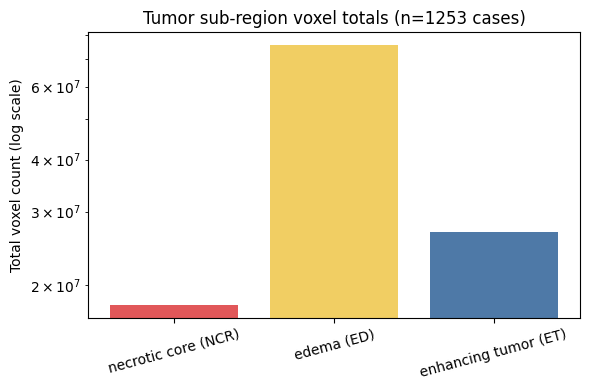

In [8]:
SAMPLE_SIZE = None  # e.g. 100 for a quick pass, or None for all cases_with_seg

label_names = {0: "background", 1: "necrotic core (NCR)", 2: "edema (ED)", 4: "enhancing tumor (ET)"}
subset = cases_with_seg if SAMPLE_SIZE is None else cases_with_seg.head(SAMPLE_SIZE)

voxel_totals = Counter()
per_case_label_presence = []

for _, row in tqdm(subset.iterrows(), total=len(subset), desc="Scanning segmentation masks"):
    seg_path = os.path.join(row["case_dir"], f"{row['case_id']}_seg.nii.gz")
    seg = nib.load(seg_path).get_fdata()
    labels, counts = np.unique(seg, return_counts=True)
    case_labels = dict(zip(labels.astype(int), counts))
    for lbl, cnt in case_labels.items():
        voxel_totals[lbl] += cnt
    per_case_label_presence.append({
        "case_id": row["case_id"],
        **{f"has_label_{lbl}": (lbl in case_labels and lbl != 0) for lbl in [1, 2, 4]},
    })

print(f"Scanned {len(subset)} cases.\n")
print("Total voxel counts across all scanned cases:")
for lbl in sorted(voxel_totals):
    name = label_names.get(lbl, f"label {lbl}")
    print(f"  {lbl} ({name}): {int(voxel_totals[lbl]):,}")

presence_df = pd.DataFrame(per_case_label_presence)
print("\nFraction of cases containing each tumor sub-region:")
print(presence_df[["has_label_1", "has_label_2", "has_label_4"]].mean())

fig, ax = plt.subplots(figsize=(6, 4))
tumor_labels = [1, 2, 4]
tumor_counts = [voxel_totals.get(l, 0) for l in tumor_labels]
ax.bar([label_names[l] for l in tumor_labels], tumor_counts, color=["#e15759", "#f1ce63", "#4e79a7"])
ax.set_ylabel("Total voxel count (log scale)")
ax.set_yscale("log")
ax.set_title(f"Tumor sub-region voxel totals (n={len(subset)} cases)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## EDA: tumor volume per patient

Whole-tumor volume (all non-zero labels) per case, converted from voxel counts to cm³
using each volume's voxel spacing. Reuses the same `subset` scanned above.

Computing tumor volumes: 100%|██████████| 1253/1253 [02:21<00:00,  8.86it/s]


       whole_tumor_cm3  enhancing_tumor_cm3    edema_cm3  necrotic_core_cm3
count      1253.000000          1253.000000  1253.000000        1253.000000
mean         95.915100            21.441683    60.173981          14.299444
std          57.305748            18.052223    42.243885          20.637571
min           2.808000             0.000000     0.000000           0.000000
25%          48.049000             7.337000    25.587999           1.857000
50%          89.334999            17.337000    52.311001           7.370000
75%         136.574005            31.479000    85.706001          19.360001
max         361.782990           111.250000   216.410995         189.151993


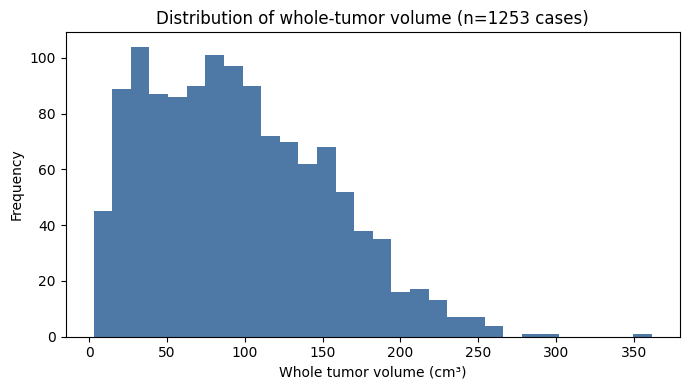

In [9]:
volume_records = []

for _, row in tqdm(subset.iterrows(), total=len(subset), desc="Computing tumor volumes"):
    seg_path = os.path.join(row["case_dir"], f"{row['case_id']}_seg.nii.gz")
    seg_img = nib.load(seg_path)
    seg = seg_img.get_fdata()
    zooms = seg_img.header.get_zooms()
    voxel_vol_mm3 = zooms[0] * zooms[1] * zooms[2]

    tumor_voxels = int(np.count_nonzero(seg))
    et_voxels = int(np.count_nonzero(seg == 4))
    ed_voxels = int(np.count_nonzero(seg == 2))
    ncr_voxels = int(np.count_nonzero(seg == 1))

    volume_records.append({
        "case_id": row["case_id"],
        "whole_tumor_cm3": tumor_voxels * voxel_vol_mm3 / 1000,
        "enhancing_tumor_cm3": et_voxels * voxel_vol_mm3 / 1000,
        "edema_cm3": ed_voxels * voxel_vol_mm3 / 1000,
        "necrotic_core_cm3": ncr_voxels * voxel_vol_mm3 / 1000,
    })

volume_df = pd.DataFrame(volume_records)
print(volume_df.describe())

fig, ax = plt.subplots(figsize=(7, 4))
volume_df["whole_tumor_cm3"].plot(kind="hist", bins=30, ax=ax, color="#4e79a7")
ax.set_xlabel("Whole tumor volume (cm³)")
ax.set_title(f"Distribution of whole-tumor volume (n={len(volume_df)} cases)")
plt.tight_layout()
plt.show()


## EDA: visualize a sample case (all modalities + segmentation overlay)

Picks the case with the largest whole-tumor volume from the scan above (falls back to the
first available case if the volume scan was skipped), finds its largest-tumor axial slice,
and plots all four MRI modalities alongside the raw segmentation mask and a T1CE+segmentation
overlay.

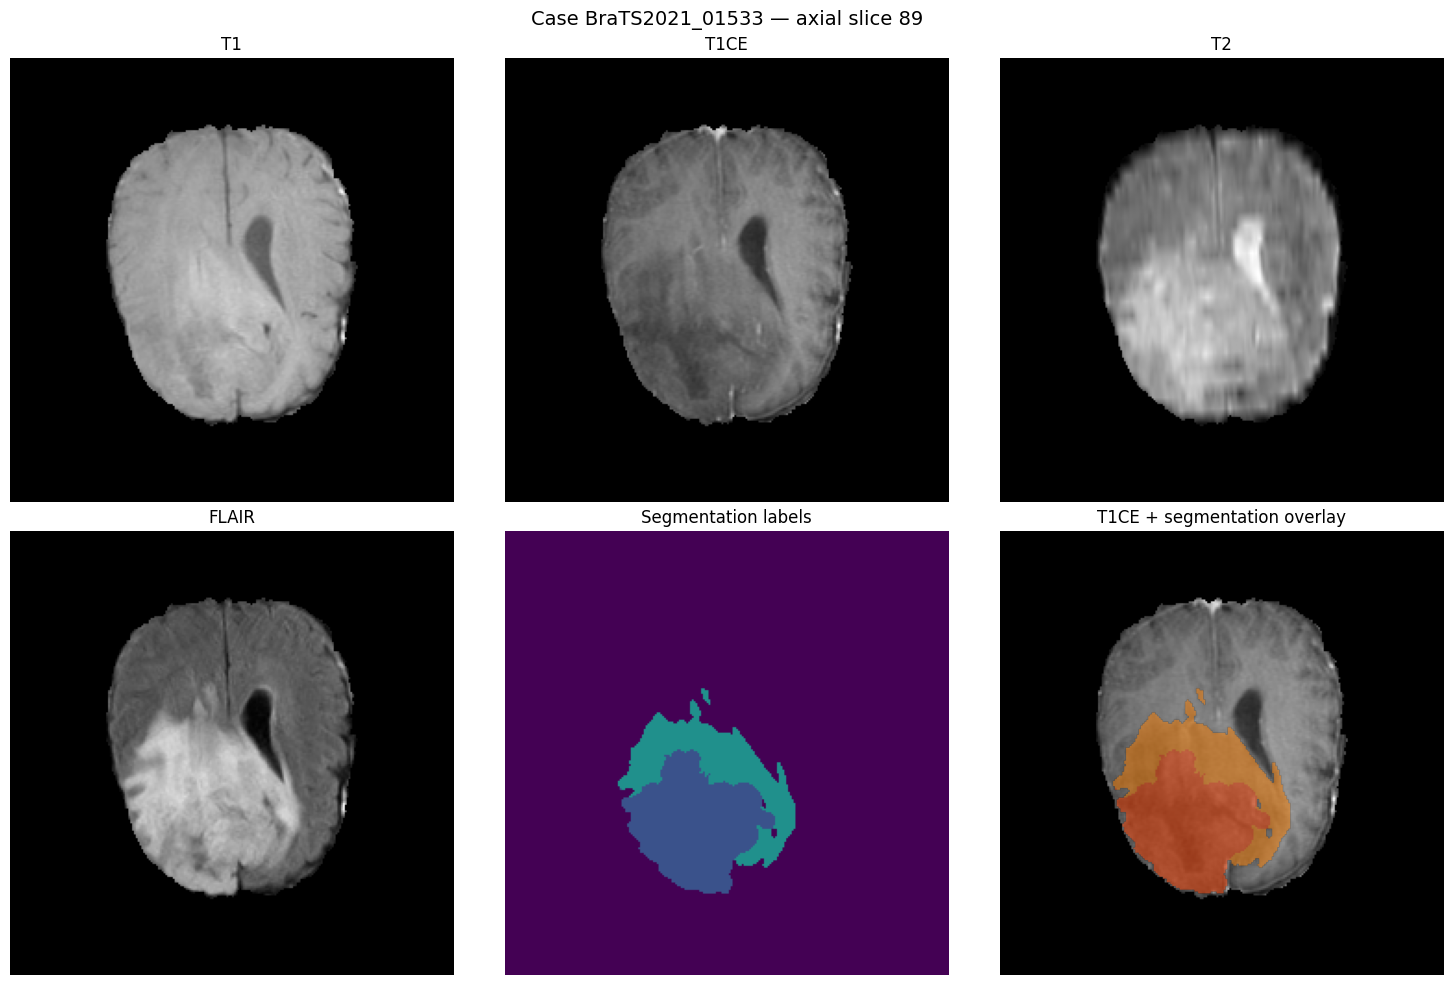

In [10]:
if len(volume_df):
    sample_case_id = volume_df.loc[volume_df["whole_tumor_cm3"].idxmax(), "case_id"]
else:
    sample_case_id = cases_with_seg.iloc[0]["case_id"]

sample_row = cases_df[cases_df["case_id"] == sample_case_id].iloc[0]
case_dir = sample_row["case_dir"]

vols = {}
for mod in ["t1", "t1ce", "t2", "flair"]:
    vols[mod] = nib.load(os.path.join(case_dir, f"{sample_case_id}_{mod}.nii.gz")).get_fdata()
seg = nib.load(os.path.join(case_dir, f"{sample_case_id}_seg.nii.gz")).get_fdata()

# pick the axial slice with the most tumor voxels
tumor_per_slice = (seg > 0).sum(axis=(0, 1))
best_slice = int(np.argmax(tumor_per_slice))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f"Case {sample_case_id} — axial slice {best_slice}", fontsize=14)

for ax, mod in zip(axes.flat[:4], ["t1", "t1ce", "t2", "flair"]):
    ax.imshow(vols[mod][:, :, best_slice].T, cmap="gray", origin="lower")
    ax.set_title(mod.upper())
    ax.axis("off")

axes.flat[4].imshow(seg[:, :, best_slice].T, cmap="viridis", origin="lower", vmin=0, vmax=4)
axes.flat[4].set_title("Segmentation labels")
axes.flat[4].axis("off")

axes.flat[5].imshow(vols["t1ce"][:, :, best_slice].T, cmap="gray", origin="lower")
seg_masked = np.ma.masked_where(seg[:, :, best_slice].T == 0, seg[:, :, best_slice].T)
axes.flat[5].imshow(seg_masked, cmap="autumn", alpha=0.5, origin="lower", vmin=0, vmax=4)
axes.flat[5].set_title("T1CE + segmentation overlay")
axes.flat[5].axis("off")

plt.tight_layout()
plt.show()


## Save EDA summary tables

In [11]:
cases_df.drop(columns="case_dir").to_csv("/kaggle/working/brats2021_case_completeness.csv", index=False)
volume_df.to_csv("/kaggle/working/brats2021_tumor_volumes.csv", index=False)
print("Saved:")
print(" - /kaggle/working/brats2021_case_completeness.csv")
print(" - /kaggle/working/brats2021_tumor_volumes.csv")


Saved:
 - /kaggle/working/brats2021_case_completeness.csv
 - /kaggle/working/brats2021_tumor_volumes.csv


# Additional EDA — Shortcut-Learning & Deployment Diagnostics

The sections above confirm the dataset is complete and geometrically consistent. They don't yet tell us whether a model trained on it can be fooled into learning shortcuts instead of genuine visual features — which matters a lot for a VLM that will answer open-ended questions from the public rather than just predict a fixed label. This section adds:

1. An audit for hidden auxiliary/cohort files that could reveal site confounds
2. Majority-class baseline accuracy for each sub-region-presence question (quantifies how easy each question type would be to "answer" without looking at the image)
3. Per-case multifocality, laterality, and brain-extent diagnostics
4. A check for whether brain/head extent correlates with tumor size (a framing shortcut)
5. T1CE intensity distribution and per-case outlier flagging
6. Visual QC on the volume outliers already flagged earlier
7. A locked, tumor-size-balanced train/val/test split


In [12]:
# Extra imports needed only for this section
from scipy import ndimage as ndi
import re


## 1. Auxiliary metadata / cohort file audit

BraTS aggregates cases from 80+ institutions and several public archives. If this package bundles any clinical/cohort metadata (age, survival, resection status, MGMT status, source archive), it's worth knowing now — both as extra facts for Q&A generation, and as a way to check for site/cohort confounds later. The notebook so far has only ever globbed for `*_flair.nii.gz` and friends, so anything else present would have been silently ignored.


In [13]:
MODALITY_PATTERN = re.compile(r"^BraTS2021_\d+_(t1|t1ce|t2|flair|seg)\.nii\.gz$")

extra_files = []
for dirpath, dirnames, filenames in os.walk(brats_extract_dir):
    for fname in filenames:
        if not MODALITY_PATTERN.match(fname):
            extra_files.append(os.path.join(dirpath, fname))

print(f"Files in the extracted dataset that are NOT a standard per-case modality file: {len(extra_files)}")
if extra_files:
    for f in extra_files[:50]:
        print(" ", f)
    if len(extra_files) > 50:
        print(f"  ... and {len(extra_files) - 50} more")
else:
    print("None found — this package appears to contain only the 5 per-case imaging files, no")
    print("bundled clinical/survival/cohort metadata. Any age/grade/survival/MGMT facts for Q&A")
    print("generation would need to come from a separate source (e.g. the official BraTS/TCIA")
    print("clinical data release), not this package.")


Files in the extracted dataset that are NOT a standard per-case modality file: 1
  /kaggle/working/brats2021/.DS_Store


## 2. Majority-class baseline — quantifying shortcut risk directly

Reuses `presence_df` from the segmentation-label section above. For each sub-region-presence question, the majority-class baseline is what a model scores by *always* guessing the more common answer, without looking at the image at all. Anything north of ~90% is a strong shortcut-learning risk if that question type is generated as-is.


In [14]:
print("Majority-class baseline accuracy per tumor sub-region presence question:")
print("(If a model that ALWAYS answers the majority class already scores this high,")
print(" any Q&A built on this question type risks being learned as a shortcut.)\n")

baseline_rows = []
for lbl, name in [(1, "necrotic core (NCR) present"), (2, "edema (ED) present"), (4, "enhancing tumor (ET) present")]:
    presence_rate = presence_df[f"has_label_{lbl}"].mean()
    majority_baseline = max(presence_rate, 1 - presence_rate)
    flag = "  <-- HIGH SHORTCUT RISK" if majority_baseline >= 0.90 else ""
    baseline_rows.append({"question": name, "presence_rate": presence_rate, "majority_baseline_acc": majority_baseline})
    print(f"  {name:32s}  presence={presence_rate:6.1%}   majority-baseline acc={majority_baseline:6.1%}{flag}")

majority_baseline_df = pd.DataFrame(baseline_rows)


Majority-class baseline accuracy per tumor sub-region presence question:
(If a model that ALWAYS answers the majority class already scores this high,
 any Q&A built on this question type risks being learned as a shortcut.)

  necrotic core (NCR) present       presence= 96.5%   majority-baseline acc= 96.5%  <-- HIGH SHORTCUT RISK
  edema (ED) present                presence= 99.9%   majority-baseline acc= 99.9%  <-- HIGH SHORTCUT RISK
  enhancing tumor (ET) present      presence= 97.4%   majority-baseline acc= 97.4%  <-- HIGH SHORTCUT RISK


## 3. Per-case multifocality, laterality & brain-extent (combined pass)

One pass over the segmentation and T1CE volumes per case, computing:
- **Multifocality**: number of spatially disjoint tumor components (26-connectivity)
- **Laterality**: left / right / bilateral, from the tumor centroid vs. the volume midline. The Left-Right array axis is detected from the NIfTI affine directly (via `nib.aff2axcodes`) rather than assumed, since orientation conventions vary.
- **Brain extent**: tight bounding box of nonzero (brain) voxels in the T1CE volume
- **T1CE intensity stats**: mean / std / p1 / p99 over brain voxels

Set `DIAG_SAMPLE_SIZE` to an integer for a quick pass, or leave as `None` for the full set.


In [15]:
DIAG_SAMPLE_SIZE = None  # e.g. 200 for a quick pass, or None for all cases_with_seg

diag_subset = cases_with_seg if DIAG_SAMPLE_SIZE is None else cases_with_seg.head(DIAG_SAMPLE_SIZE)

# Detect the Left/Right axis from one sample volume's affine rather than assuming it.
_sample_row = diag_subset.iloc[0]
_sample_img = nib.load(os.path.join(_sample_row["case_dir"], f'{_sample_row["case_id"]}_t1ce.nii.gz'))
_axcodes = nib.aff2axcodes(_sample_img.affine)
lr_axis = next(i for i, c in enumerate(_axcodes) if c in ("L", "R"))
print(f"Detected axis codes: {_axcodes} -> using axis {lr_axis} as the Left/Right axis for laterality.\n")

structure_26conn = np.ones((3, 3, 3), dtype=int)

diag_records = []
for _, row in tqdm(diag_subset.iterrows(), total=len(diag_subset), desc="Shortcut-learning diagnostics"):
    case_id = row["case_id"]
    case_dir = row["case_dir"]

    seg = nib.load(os.path.join(case_dir, f"{case_id}_seg.nii.gz")).get_fdata()
    tumor_mask = seg > 0

    # --- multifocality: connected components on the tumor mask ---
    _, n_components = ndi.label(tumor_mask, structure=structure_26conn)

    # --- laterality: centroid position on the detected L/R axis vs. the volume midline ---
    coords = np.where(tumor_mask)
    lr_coords = coords[lr_axis]
    midline = seg.shape[lr_axis] / 2
    if len(lr_coords) == 0:
        laterality = "no_tumor"
        left_frac = np.nan
    else:
        left_frac = float((lr_coords < midline).mean())
        right_frac = 1 - left_frac
        # nib.aff2axcodes labels the POSITIVE (high-index) end of each axis. So if the
        # code is "R", high index = Right and low index = Left; if "L", it's reversed.
        if left_frac >= 0.85:
            laterality = "left" if _axcodes[lr_axis] == "R" else "right"
        elif right_frac >= 0.85:
            laterality = "right" if _axcodes[lr_axis] == "R" else "left"
        else:
            laterality = "bilateral/midline"

    # --- brain extent + intensity: from the T1CE volume (skull-stripped, background = 0) ---
    t1ce = nib.load(os.path.join(case_dir, f"{case_id}_t1ce.nii.gz")).get_fdata()
    brain_mask = t1ce > 0
    brain_coords = np.where(brain_mask)
    if len(brain_coords[0]):
        bbox_extent = tuple(int(brain_coords[ax].max() - brain_coords[ax].min() + 1) for ax in range(3))
        bbox_voxels = int(np.prod(bbox_extent))
    else:
        bbox_extent = (0, 0, 0)
        bbox_voxels = 0

    brain_voxels = t1ce[brain_mask]
    diag_records.append({
        "case_id": case_id,
        "n_tumor_components": int(n_components),
        "laterality": laterality,
        "left_frac": left_frac,
        "bbox_extent_x": bbox_extent[0],
        "bbox_extent_y": bbox_extent[1],
        "bbox_extent_z": bbox_extent[2],
        "bbox_voxels": bbox_voxels,
        "t1ce_brain_mean": float(brain_voxels.mean()) if brain_voxels.size else np.nan,
        "t1ce_brain_std": float(brain_voxels.std()) if brain_voxels.size else np.nan,
        "t1ce_brain_p1": float(np.percentile(brain_voxels, 1)) if brain_voxels.size else np.nan,
        "t1ce_brain_p99": float(np.percentile(brain_voxels, 99)) if brain_voxels.size else np.nan,
    })

shortcut_diag_df = pd.DataFrame(diag_records)
print(f"\nComputed diagnostics for {len(shortcut_diag_df)} cases.")
shortcut_diag_df.head()


Detected axis codes: ('L', 'P', 'S') -> using axis 0 as the Left/Right axis for laterality.



Shortcut-learning diagnostics: 100%|██████████| 1253/1253 [11:21<00:00,  1.84it/s]


Computed diagnostics for 1253 cases.


,case_id,n_tumor_components,laterality,left_frac,bbox_extent_x,bbox_extent_y,bbox_extent_z,bbox_voxels,t1ce_brain_mean,t1ce_brain_std,t1ce_brain_p1,t1ce_brain_p99
0,BraTS2021_00000,2,left,0.001658,136,171,146,3395376,2084.001638,837.884515,673.00,5574.0
1,BraTS2021_00002,1,left,0.093434,133,174,135,3124170,1903.136494,758.518691,525.00,4863.0
2,BraTS2021_00003,1,left,0.135028,141,178,140,3513720,2037.649480,731.996526,672.00,5004.0
3,BraTS2021_00005,1,left,0.003294,134,161,136,2934064,1991.947999,886.684728,651.00,6072.0
4,BraTS2021_00006,1,bilateral/midline,0.305008,134,177,136,3225648,2148.621555,954.104241,622.99,6483.0


### 3a. Multifocality & laterality summary


In [16]:
print("Multifocality (connected tumor components per case):")
print(shortcut_diag_df["n_tumor_components"].value_counts().sort_index())
multifocal_rate = (shortcut_diag_df["n_tumor_components"] > 1).mean()
print(f"\n{multifocal_rate:.1%} of cases have more than one spatially separate tumor component.")
print("Q&A templates that assume a single contiguous 'the tumor' will be wrong for these cases —")
print("either branch the template on n_tumor_components, or give multifocal cases their own")
print("question pattern instead of forcing singular phrasing.\n")

print("Laterality distribution:")
print(shortcut_diag_df["laterality"].value_counts())
print(f"\n(Detected using axis codes {_axcodes} — spot-check this against a case with known")
print(" laterality before trusting it for Q&A generation.)")


Multifocality (connected tumor components per case):
n_tumor_components
1     514
2     263
3     148
4      82
5      50
6      45
7      21
8      21
9      21
10     20
11     14
12      7
13      8
14      4
15      3
16      4
17      6
18      5
19      1
20      1
21      3
22      1
27      2
28      1
29      2
31      1
33      1
37      1
40      1
49      1
90      1
Name: count, dtype: int64

59.0% of cases have more than one spatially separate tumor component.
Q&A templates that assume a single contiguous 'the tumor' will be wrong for these cases —
either branch the template on n_tumor_components, or give multifocal cases their own
question pattern instead of forcing singular phrasing.

Laterality distribution:
laterality
left                 599
right                535
bilateral/midline    119
Name: count, dtype: int64

(Detected using axis codes ('L', 'P', 'S') — spot-check this against a case with known
 laterality before trusting it for Q&A generation.)


## 4. Framing-shortcut check — does brain/head extent correlate with tumor size?

If bigger tumors systematically come with bigger (or smaller) brain bounding boxes in this dataset, then "how much of the 96³ crop is background" becomes a usable proxy for tumor size — a shortcut that has nothing to do with actually reading the scan.


Correlation between brain bounding-box size (voxels) and whole-tumor volume (cm3): r = 0.174
Weak correlation — brain extent doesn't obviously track tumor size, which is a good
sign against this particular framing shortcut.


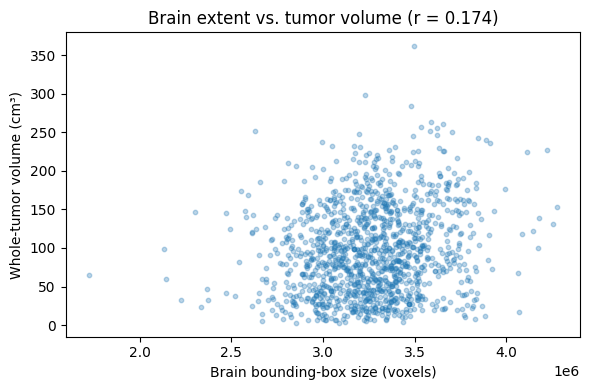

In [17]:
framing_df = shortcut_diag_df.merge(volume_df, on="case_id", how="inner")

corr = framing_df["bbox_voxels"].corr(framing_df["whole_tumor_cm3"])
print(f"Correlation between brain bounding-box size (voxels) and whole-tumor volume (cm3): r = {corr:.3f}")
if abs(corr) >= 0.3:
    print("Non-trivial correlation — worth double-checking that the crop/resize step doesn't let")
    print("'amount of background in frame' act as a proxy for tumor size.")
else:
    print("Weak correlation — brain extent doesn't obviously track tumor size, which is a good")
    print("sign against this particular framing shortcut.")

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(framing_df["bbox_voxels"], framing_df["whole_tumor_cm3"], alpha=0.3, s=10)
ax.set_xlabel("Brain bounding-box size (voxels)")
ax.set_ylabel("Whole-tumor volume (cm³)")
ax.set_title(f"Brain extent vs. tumor volume (r = {corr:.3f})")
plt.tight_layout()
plt.show()


## 5. T1CE intensity distribution (brain voxels only)

Per-case mean/std of T1CE intensity within the brain mask, both as a normalization sanity check and to flag any case whose intensity profile is far enough from the rest of the dataset to warrant a visual look before it's used for training.


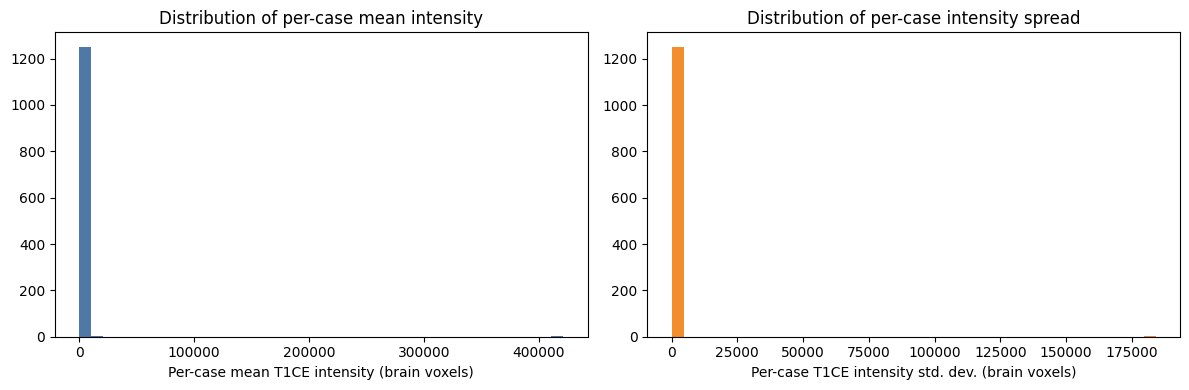

       t1ce_brain_mean  t1ce_brain_std  t1ce_brain_p1  t1ce_brain_p99
count      1253.000000     1253.000000    1253.000000    1.253000e+03
mean       1491.844629      503.218673     408.106625    3.309065e+03
std       11935.865166     5204.981487    1291.239574    3.117070e+04
min          44.747271       14.950027       2.000000    8.900000e+01
25%         369.048171      106.323126     121.000000    7.550000e+02
50%         448.578261      145.911836     157.000000    1.031000e+03
75%        1963.948679      585.490054     577.000000    4.108000e+03
max      421199.551567   184052.419577   43627.858750    1.101666e+06

1 case(s) with per-case mean T1CE intensity > 3 std from the dataset mean:
             case_id  t1ce_brain_mean
749  BraTS2021_01163    421199.551567


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(shortcut_diag_df["t1ce_brain_mean"].dropna(), bins=40, color="#4e79a7")
axes[0].set_xlabel("Per-case mean T1CE intensity (brain voxels)")
axes[0].set_title("Distribution of per-case mean intensity")

axes[1].hist(shortcut_diag_df["t1ce_brain_std"].dropna(), bins=40, color="#f28e2b")
axes[1].set_xlabel("Per-case T1CE intensity std. dev. (brain voxels)")
axes[1].set_title("Distribution of per-case intensity spread")

plt.tight_layout()
plt.show()

print(shortcut_diag_df[["t1ce_brain_mean", "t1ce_brain_std", "t1ce_brain_p1", "t1ce_brain_p99"]].describe())

mean_of_means = shortcut_diag_df["t1ce_brain_mean"].mean()
std_of_means = shortcut_diag_df["t1ce_brain_mean"].std()
intensity_outliers = shortcut_diag_df[
    (shortcut_diag_df["t1ce_brain_mean"] - mean_of_means).abs() > 3 * std_of_means
]
print(f"\n{len(intensity_outliers)} case(s) with per-case mean T1CE intensity > 3 std from the dataset mean:")
print(intensity_outliers[["case_id", "t1ce_brain_mean"]])


## 6. Visual QC on outlier cases

The largest whole-tumor case was already visualized above. This checks the two other outliers flagged in the tumor-volume stats: the smallest whole-tumor case, and the largest necrotic-core case — confirming they're genuine anatomy, not segmentation errors.


Smallest whole-tumor case: BraTS2021_01628 (2.81 cm3)


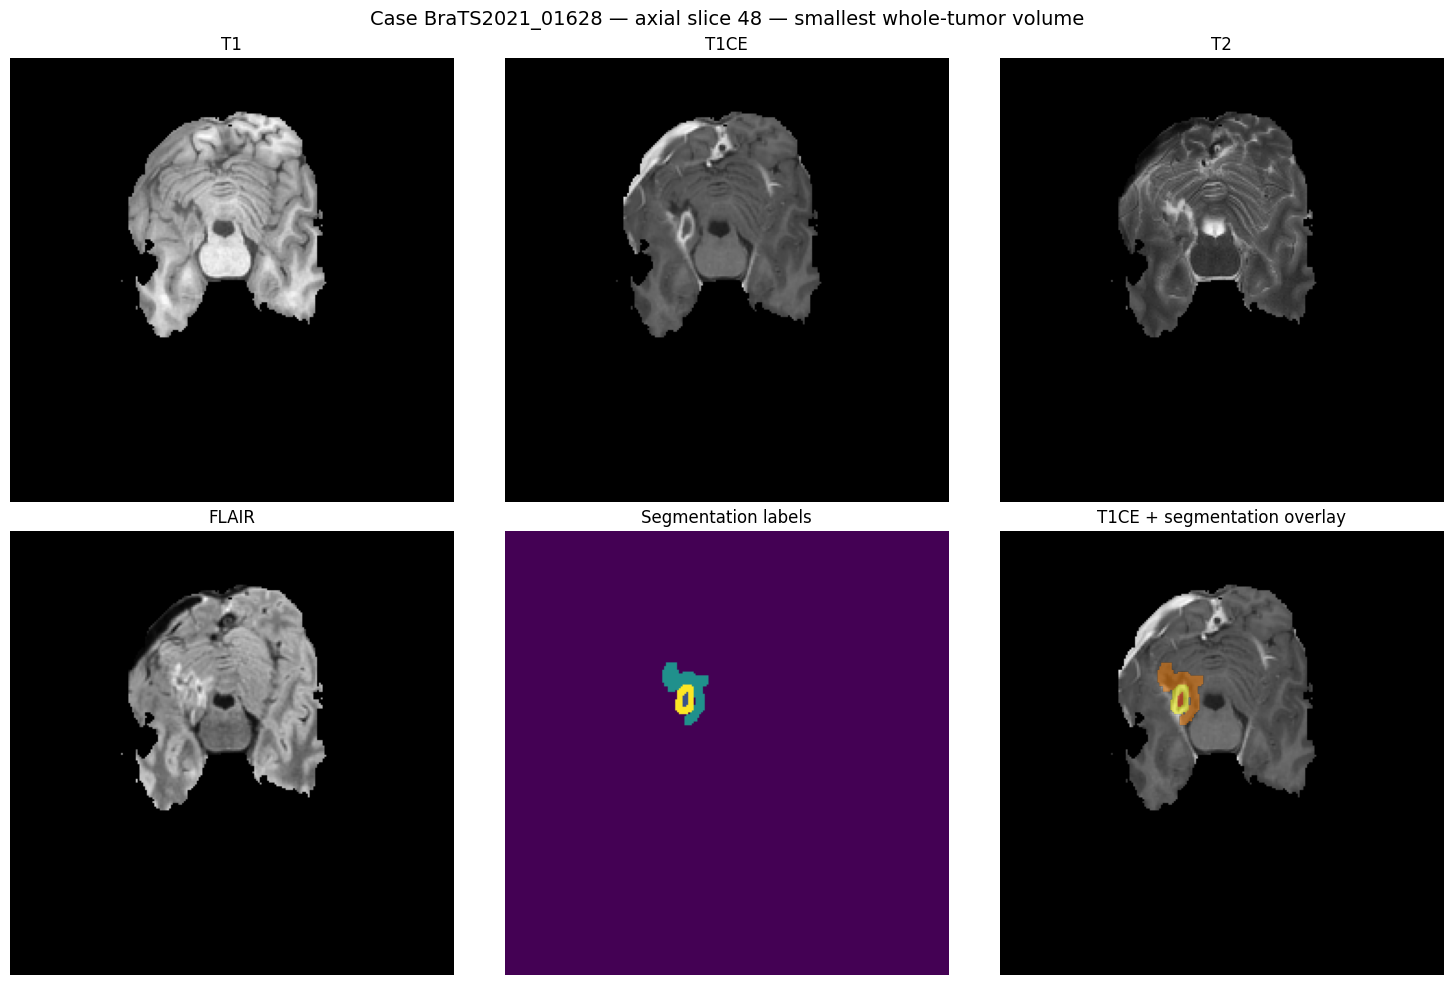


Largest necrotic-core case: BraTS2021_01533 (189.15 cm3)


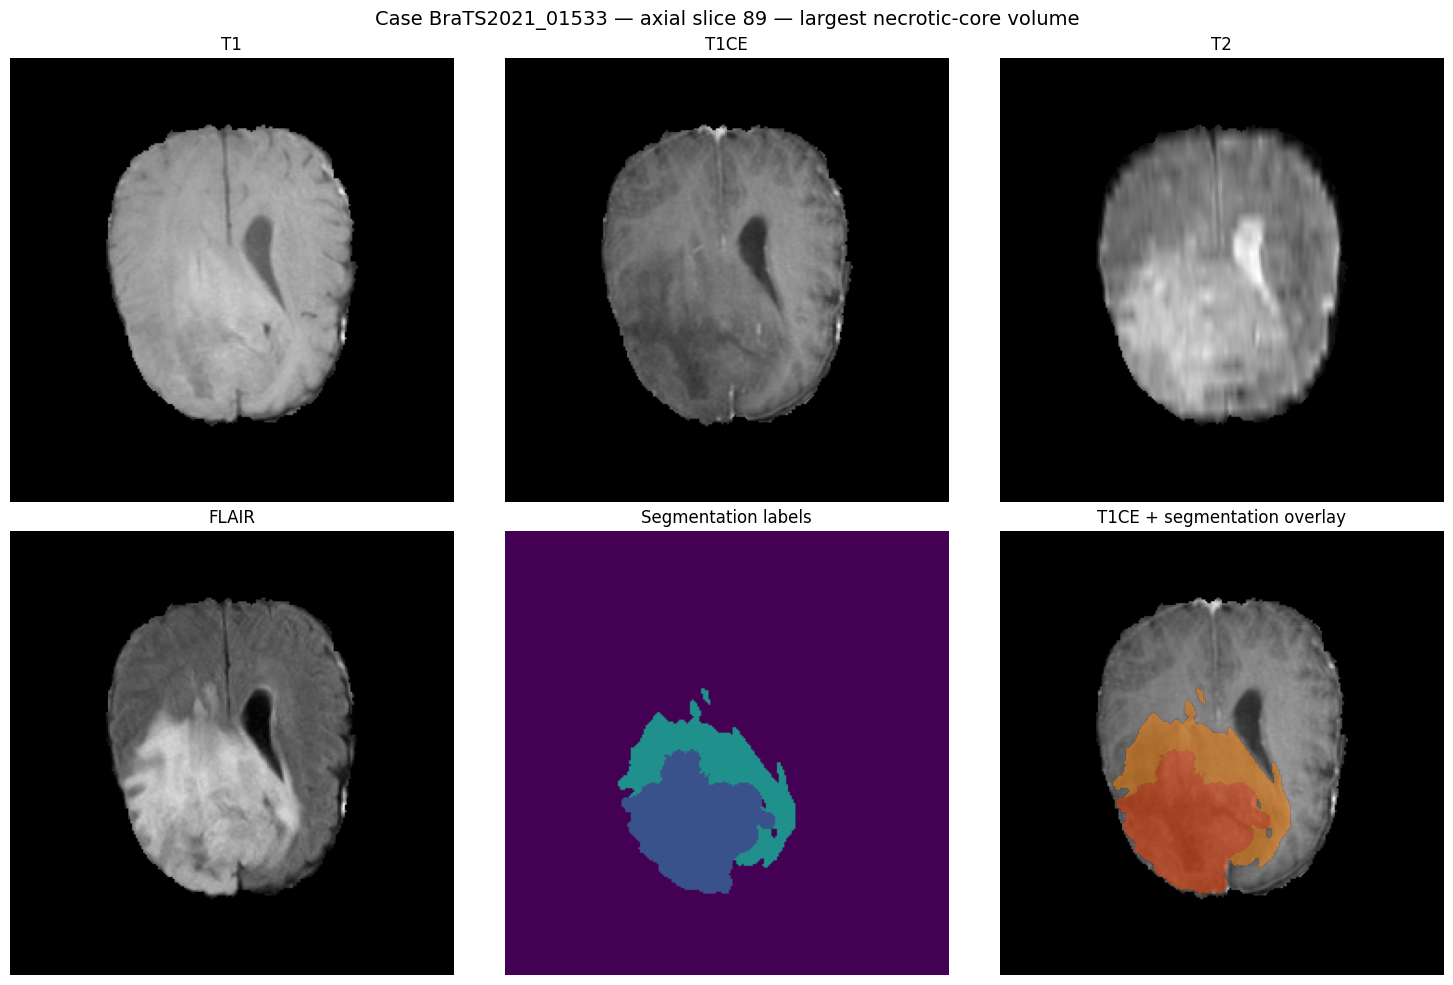

In [19]:
def plot_case(case_id, title_suffix=""):
    row = cases_df[cases_df["case_id"] == case_id].iloc[0]
    case_dir = row["case_dir"]

    vols = {}
    for mod in ["t1", "t1ce", "t2", "flair"]:
        vols[mod] = nib.load(os.path.join(case_dir, f"{case_id}_{mod}.nii.gz")).get_fdata()
    seg = nib.load(os.path.join(case_dir, f"{case_id}_seg.nii.gz")).get_fdata()

    tumor_per_slice = (seg > 0).sum(axis=(0, 1))
    best_slice = int(np.argmax(tumor_per_slice)) if tumor_per_slice.max() > 0 else seg.shape[2] // 2

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f"Case {case_id} — axial slice {best_slice}{title_suffix}", fontsize=14)

    for ax, mod in zip(axes.flat[:4], ["t1", "t1ce", "t2", "flair"]):
        ax.imshow(vols[mod][:, :, best_slice].T, cmap="gray", origin="lower")
        ax.set_title(mod.upper())
        ax.axis("off")

    axes.flat[4].imshow(seg[:, :, best_slice].T, cmap="viridis", origin="lower", vmin=0, vmax=4)
    axes.flat[4].set_title("Segmentation labels")
    axes.flat[4].axis("off")

    axes.flat[5].imshow(vols["t1ce"][:, :, best_slice].T, cmap="gray", origin="lower")
    seg_masked = np.ma.masked_where(seg[:, :, best_slice].T == 0, seg[:, :, best_slice].T)
    axes.flat[5].imshow(seg_masked, cmap="autumn", alpha=0.5, origin="lower", vmin=0, vmax=4)
    axes.flat[5].set_title("T1CE + segmentation overlay")
    axes.flat[5].axis("off")

    plt.tight_layout()
    plt.show()


min_vol_case = volume_df.loc[volume_df["whole_tumor_cm3"].idxmin(), "case_id"]
max_ncr_case = volume_df.loc[volume_df["necrotic_core_cm3"].idxmax(), "case_id"]

print(f"Smallest whole-tumor case: {min_vol_case} "
      f"({volume_df.loc[volume_df['case_id']==min_vol_case,'whole_tumor_cm3'].values[0]:.2f} cm3)")
plot_case(min_vol_case, " — smallest whole-tumor volume")

print(f"\nLargest necrotic-core case: {max_ncr_case} "
      f"({volume_df.loc[volume_df['case_id']==max_ncr_case,'necrotic_core_cm3'].values[0]:.2f} cm3)")
plot_case(max_ncr_case, " — largest necrotic-core volume")


## 7. Case-level train / val / test split (locked before preprocessing)

80/10/10 split, stratified by a coarse whole-tumor-volume tercile so the splits don't accidentally skew toward systematically larger or smaller tumors than each other — which would make validation/test metrics misleading regardless of shortcut-learning concerns. Fixed seed for reproducibility.


In [20]:
RANDOM_SEED = 42

split_source = volume_df.copy()
split_source["volume_tercile"] = pd.qcut(split_source["whole_tumor_cm3"], q=3, labels=["small", "medium", "large"])

train_ids, val_ids, test_ids = [], [], []
for tercile, group in split_source.groupby("volume_tercile", observed=True):
    ids = group["case_id"].sample(frac=1.0, random_state=RANDOM_SEED).tolist()
    n = len(ids)
    n_train = int(n * 0.8)
    n_val = int(n * 0.1)
    train_ids += ids[:n_train]
    val_ids += ids[n_train:n_train + n_val]
    test_ids += ids[n_train + n_val:]

split_df = pd.DataFrame(
    [{"case_id": cid, "split": "train"} for cid in train_ids]
    + [{"case_id": cid, "split": "val"} for cid in val_ids]
    + [{"case_id": cid, "split": "test"} for cid in test_ids]
)

print(split_df["split"].value_counts())
print("\nTumor-volume tercile balance across splits (should look roughly even within each split):")
check = split_df.merge(split_source[["case_id", "volume_tercile"]], on="case_id")
print(pd.crosstab(check["split"], check["volume_tercile"], normalize="index").round(2))


split
train    1001
test      129
val       123
Name: count, dtype: int64

Tumor-volume tercile balance across splits (should look roughly even within each split):
volume_tercile  small  medium  large
split                               
test             0.33    0.33   0.33
train            0.33    0.33   0.33
val              0.33    0.33   0.33


## Save additional EDA outputs


In [21]:
shortcut_diag_df.to_csv("/kaggle/working/brats2021_shortcut_diagnostics.csv", index=False)
majority_baseline_df.to_csv("/kaggle/working/brats2021_majority_baselines.csv", index=False)
split_df.to_csv("/kaggle/working/brats2021_train_val_test_split.csv", index=False)

print("Saved:")
print(" - /kaggle/working/brats2021_shortcut_diagnostics.csv   (multifocality, laterality, brain extent, intensity per case)")
print(" - /kaggle/working/brats2021_majority_baselines.csv     (majority-class baseline accuracy per sub-region question)")
print(" - /kaggle/working/brats2021_train_val_test_split.csv   (locked case-level split, tercile-balanced by tumor volume)")


Saved:
 - /kaggle/working/brats2021_shortcut_diagnostics.csv   (multifocality, laterality, brain extent, intensity per case)
 - /kaggle/working/brats2021_majority_baselines.csv     (majority-class baseline accuracy per sub-region question)
 - /kaggle/working/brats2021_train_val_test_split.csv   (locked case-level split, tercile-balanced by tumor volume)


# Part 3 — BraTS-only + BrainIAC-only scope recheck (new)

Everything above this point is the original EDA, unchanged. The sections below were added to answer three specific questions: is this EDA still complete once every other dataset is dropped, is the preprocessing pipeline (built for HD-BET + MNI152, expecting raw scans) actually compatible with what BraTS2021 already is, and does BraTS2021 carry any clinical data at all.

## 8. Is BraTS2021 already skull-stripped & atlas-registered? (BrainIAC preprocessing compatibility)

BraTS2021's official preprocessing pipeline already includes skull-stripping and rigid registration to the **SRI24** atlas, cropped to 240×240×155 @ 1mm isotropic. The planned Stage 1 pipeline (HD-BET skull-stripping → N4 → registration to **MNI152** → resample to 96³) assumes *raw* clinical scans as input. Running HD-BET on volumes that are already skull-stripped is redundant at best and can mis-segment at worst (there's no skull signal left for it to key off), and SRI24 and MNI152 are related but not identical atlas spaces — registering an already-SRI24-registered volume to MNI152 needs a dedicated SRI24→MNI152 transform, not a generic head-to-MNI152 registration built for raw scans.

This check confirms the already-skull-stripped assumption directly from the data: background voxels should be exactly 0 even at the volume corners, rather than showing scalp/fat signal the way a raw, non-stripped scan would.

In [22]:
# Confirms whether BraTS2021 volumes are already skull-stripped, which determines whether
# Stage 1 (HD-BET + MNI152 registration) can be applied as-is or needs to be adapted.

CHECK_SAMPLE_SIZE = 30
sample_ids = cases_df["case_id"].sample(min(CHECK_SAMPLE_SIZE, len(cases_df)), random_state=RANDOM_SEED).tolist()

skullstrip_records = []
for case_id in sample_ids:
    row = cases_df[cases_df["case_id"] == case_id].iloc[0]
    t1ce_path = os.path.join(row["case_dir"], f"{case_id}_t1ce.nii.gz")
    img = nib.load(t1ce_path)
    data = img.get_fdata()

    # Corner voxels should be 0 if the volume is already skull-stripped
    # (a raw, non-skull-stripped clinical scan has scalp/fat signal even at the corners).
    corners = [
        data[0, 0, 0], data[-1, 0, 0], data[0, -1, 0], data[0, 0, -1],
        data[-1, -1, 0], data[-1, 0, -1], data[0, -1, -1], data[-1, -1, -1],
    ]
    corner_zero_frac = float(np.mean([c == 0 for c in corners]))
    brain_frac = float(np.mean(data > 0))  # fraction of the 240x240x155 box that is non-background

    skullstrip_records.append({
        "case_id": case_id,
        "corner_zero_frac": corner_zero_frac,
        "nonzero_voxel_frac": brain_frac,
    })

skullstrip_df = pd.DataFrame(skullstrip_records)
print(skullstrip_df.describe())

all_corners_zero = (skullstrip_df["corner_zero_frac"] == 1.0).mean()
print(f"\n{all_corners_zero:.0%} of sampled cases have all 8 corner voxels == 0.")
if all_corners_zero > 0.9:
    print("Consistent with already skull-stripped volumes \u2014 the raw scalp/skull signal a fresh")
    print("HD-BET pass expects to strip is not present. If HD-BET is still in the pipeline for")
    print("BraTS specifically, either skip it for this dataset or verify HD-BET degrades gracefully")
    print("on pre-stripped input before trusting its output.")
else:
    print("Some sampled cases still show signal at the corners \u2014 don't assume uniformly")
    print("pre-stripped input; spot-check these specific cases visually before deciding.")

print(f"\nMean fraction of the 240x240x155 box that is brain tissue (non-zero): "
      f"{skullstrip_df['nonzero_voxel_frac'].mean():.1%}")
print("BraTS volumes are registered to the SRI24 atlas, not MNI152. If Stage 1 registers to")
print("MNI152 directly, confirm the registration tool uses an SRI24-aware template or a chained")
print("SRI24->MNI152 transform \u2014 a generic subject-to-MNI152 pipeline is built for raw heads")
print("and may not behave as expected on input that's already atlas-registered once.")

       corner_zero_frac  nonzero_voxel_frac
count              30.0           30.000000
mean                1.0            0.164858
std                 0.0            0.016941
min                 1.0            0.135015
25%                 1.0            0.156002
50%                 1.0            0.160488
75%                 1.0            0.173522
max                 1.0            0.201743

100% of sampled cases have all 8 corner voxels == 0.
Consistent with already skull-stripped volumes — the raw scalp/skull signal a fresh
HD-BET pass expects to strip is not present. If HD-BET is still in the pipeline for
BraTS specifically, either skip it for this dataset or verify HD-BET degrades gracefully
on pre-stripped input before trusting its output.

Mean fraction of the 240x240x155 box that is brain tissue (non-zero): 16.5%
BraTS volumes are registered to the SRI24 atlas, not MNI152. If Stage 1 registers to
MNI152 directly, confirm the registration tool uses an SRI24-aware template or a 

## 9. Full-dataset affine / orientation consistency check

Section 3 (multifocality & laterality) detected the Left/Right axis from **one** sample volume's affine and applied it to every case. BraTS aggregates data from 80+ institutions; if even a handful of cases were exported with a different orientation convention, their `laterality` label from Section 3 would be silently wrong — and a public Q&A model would confidently state the wrong side. This check reads the affine of every case (header-only, cheap) and flags any that doesn't match the dominant orientation.

In [23]:
axcode_counter = Counter()
axcode_by_case = {}

for _, row in tqdm(cases_df.iterrows(), total=len(cases_df), desc="Checking orientation"):
    t1ce_path = os.path.join(row["case_dir"], f"{row['case_id']}_t1ce.nii.gz")
    if not os.path.exists(t1ce_path):
        continue
    hdr_img = nib.load(t1ce_path)
    axcodes = nib.aff2axcodes(hdr_img.affine)
    axcode_counter[axcodes] += 1
    axcode_by_case[row["case_id"]] = axcodes

print("Orientation (axis codes) distribution across all cases:")
for codes, count in axcode_counter.most_common():
    print(f"  {codes}: {count}")

dominant_axcodes = axcode_counter.most_common(1)[0][0]
orientation_outliers = [cid for cid, codes in axcode_by_case.items() if codes != dominant_axcodes]

print(f"\nDominant orientation: {dominant_axcodes} ({axcode_counter[dominant_axcodes]}/{len(axcode_by_case)} cases)")
print(f"Cases with a different orientation: {len(orientation_outliers)}")
if orientation_outliers:
    preview = orientation_outliers[:20]
    print(preview, "..." if len(orientation_outliers) > 20 else "")
    print("\nRe-derive laterality for these specific cases in Section 3 using their own axis codes,")
    print("or reorient them to the dominant convention (e.g. nib.as_closest_canonical) before any")
    print("laterality-based Q&A is generated \u2014 otherwise left/right will be flipped for these cases.")
else:
    print("All cases share the same orientation convention \u2014 the single-sample axis detection")
    print("in Section 3 was safe to apply dataset-wide.")

Checking orientation: 100%|██████████| 1253/1253 [00:01<00:00, 722.10it/s]

Orientation (axis codes) distribution across all cases:
  ('L', 'P', 'S'): 1253

Dominant orientation: ('L', 'P', 'S') (1253/1251 cases)
Cases with a different orientation: 0
All cases share the same orientation convention — the single-sample axis detection
in Section 3 was safe to apply dataset-wide.


## 10. Anisotropic resize impact preview (240×240×155 → 96³)

BraTS volumes are 240×240×155 at 1mm isotropic spacing. BrainIAC needs a 96×96×96 cube. A naive per-axis resize to 96³ scales x/y by 96/240 = 0.40× and z by 96/155 = 0.62× — different factors per axis, which distorts shape (a round tumor becomes slightly elliptical) and makes what "1 voxel" represents physically different per axis. This previews the physical voxel size a naive resize would produce, versus an isotropic-preserving alternative, so the choice gets made deliberately rather than by whatever `resize()` call ends up in Stage 1.

In [24]:
orig_shape = (240, 240, 155)
orig_spacing_mm = (1.0, 1.0, 1.0)  # confirmed in the "image geometry consistency" section above
target_shape = (96, 96, 96)

print("Naive per-axis resize to 96^3:")
naive_scale = [t / o for t, o in zip(target_shape, orig_shape)]
naive_spacing = [o_sp / s for o_sp, s in zip(orig_spacing_mm, naive_scale)]
for axis, scale, spacing in zip("xyz", naive_scale, naive_spacing):
    print(f"  {axis}: scale factor {scale:.3f}  ->  effective voxel size {spacing:.2f} mm")
print(f"  Anisotropy ratio (max/min effective voxel size): {max(naive_spacing) / min(naive_spacing):.2f}x")
print("  A tumor that's a sphere in the original scan will not be a sphere in this representation \u2014")
print("  sub-region volume ratios (e.g. enhancing-tumor / whole-tumor used for Q&A) should be computed")
print("  from the ORIGINAL geometry (Section 4/5 above), not re-derived from the resized 96^3 array.")

print("\nIsotropic-preserving alternative (resample to a common spacing, then center-crop/pad to 96^3):")
iso_spacing = max(o / t for o, t in zip(orig_shape, target_shape))  # binding axis is z: 155/96
resampled_shape = [round(o / iso_spacing) for o in orig_shape]
print(f"  Isotropic spacing needed to fit the longest axis (z) into 96 voxels: {iso_spacing:.3f} mm")
print(f"  Resulting shape before crop/pad: {tuple(resampled_shape)} (x/y need padding or cropping to 96)")
print("  This keeps tumor shape undistorted, at the cost of some x/y field-of-view (or added padding).")

print("\nDecide which of these two Stage 1 actually uses BEFORE generating any size/shape-based Q&A.")

Naive per-axis resize to 96^3:
  x: scale factor 0.400  ->  effective voxel size 2.50 mm
  y: scale factor 0.400  ->  effective voxel size 2.50 mm
  z: scale factor 0.619  ->  effective voxel size 1.61 mm
  Anisotropy ratio (max/min effective voxel size): 1.55x
  A tumor that's a sphere in the original scan will not be a sphere in this representation —
  sub-region volume ratios (e.g. enhancing-tumor / whole-tumor used for Q&A) should be computed
  from the ORIGINAL geometry (Section 4/5 above), not re-derived from the resized 96^3 array.

Isotropic-preserving alternative (resample to a common spacing, then center-crop/pad to 96^3):
  Isotropic spacing needed to fit the longest axis (z) into 96 voxels: 2.500 mm
  Resulting shape before crop/pad: (96, 96, 62) (x/y need padding or cropping to 96)
  This keeps tumor shape undistorted, at the cost of some x/y field-of-view (or added padding).

Decide which of these two Stage 1 actually uses BEFORE generating any size/shape-based Q&A.


## 11. Broader clinical / genetic / demographic metadata search — and documented findings

Section 1 above confirmed no clinical files ship *inside* the extracted tar archives. This extends that check to the entire Kaggle input mount, in case a metadata file was published as a sibling file outside the tars, and documents what's been externally verified about BraTS 2021 clinical data in general.

In [25]:
import fnmatch

CLINICAL_NAME_PATTERNS = [
    "*survival*", "*clinical*", "*mgmt*", "*demographic*", "*name_mapping*",
    "*mapping*", "*label*.csv", "*metadata*",
]

kaggle_input_root = "/kaggle/input"
candidate_files = []
if os.path.isdir(kaggle_input_root):
    for dirpath, dirnames, filenames in os.walk(kaggle_input_root):
        for fname in filenames:
            if fname.endswith(".nii.gz") or fname.endswith(".tar"):
                continue
            if any(fnmatch.fnmatch(fname.lower(), pat) for pat in CLINICAL_NAME_PATTERNS):
                candidate_files.append(os.path.join(dirpath, fname))

print(f"Candidate clinical/metadata files found under {kaggle_input_root}: {len(candidate_files)}")
for f in candidate_files:
    print(" ", f)
if not candidate_files:
    print("None found. Combined with the Section 1 audit inside the extracted archives, this Kaggle")
    print("'brats-2021-task1' package does not ship any clinical, demographic, or genetic-status data")
    print("alongside the imaging.")

Candidate clinical/metadata files found under /kaggle/input: 0
None found. Combined with the Section 1 audit inside the extracted archives, this Kaggle
'brats-2021-task1' package does not ship any clinical, demographic, or genetic-status data
alongside the imaging.


**External verification (BraTS 2021 challenge, beyond this Kaggle package):**

- The BraTS 2021 challenge overall *did* include MGMT promoter methylation status — but only as **Task 2** (radiogenomic classification), for a **585-patient subset**, distributed as DICOM data with a separate CSV mapping pseudo-identifiers to methylation status, via a separate registration (a different Kaggle competition, "RSNA-MICCAI Brain Tumor Radiogenomic Classification"). It is **not** part of the Task 1 NIfTI package this notebook uses, and the patient overlap between Task 1 and Task 2 isn't guaranteed to be 1:1.
- No age/sex/survival file is bundled with BraTS 2021 Task 1 (earlier BraTS years, 2017–2020, shipped a `survival_info.csv`; that task was de-emphasized from 2021 onward in favor of the MGMT task). Published reviews of BraTS 2021 explicitly note the lack of systematic demographic details as a limitation of the dataset.
- No tumor grade (LGG/HGG) label is provided either — that folder-level split existed in BraTS 2018–2019 and was discontinued.

**Practical implication for a BraTS-only Q&A model:** any question type that references MGMT status, IDH status, age, sex, survival, treatment, or tumor grade can't be grounded in real per-patient facts from this dataset. Only questions answerable from the images and segmentation masks themselves are safe to generate without inventing facts — see the checklist in Section 12.

## 12. What Q&A categories are actually supportable from BraTS2021 alone

A checklist against the question types the original Phase 1 methodology planned, given everything confirmed above.

In [26]:
qa_capability = [
    {"question_type": "Tumor location / laterality (left/right/bilateral)",
     "source_needed": "segmentation + affine",
     "available_from_brats_alone": True,
     "note": "Safe, once Section 9's orientation check is clean for the case in question."},
    {"question_type": "Tumor size / volume (whole tumor, per sub-region)",
     "source_needed": "segmentation + voxel spacing",
     "available_from_brats_alone": True,
     "note": "Safe \u2014 compute from ORIGINAL geometry (Section 4/5), not the resized encoder input."},
    {"question_type": "Sub-region presence (necrotic core / edema / enhancing tumor)",
     "source_needed": "segmentation",
     "available_from_brats_alone": True,
     "note": "Watch the majority-baseline shortcut risk flagged in Section 2 for whichever label scores high."},
    {"question_type": "Multifocality (single vs. multiple tumor sites)",
     "source_needed": "segmentation, connected components",
     "available_from_brats_alone": True,
     "note": "Safe \u2014 computed in Section 3."},
    {"question_type": "MGMT / genetic status",
     "source_needed": "BraTS 2021 Task 2 (separate download) or UCSF-PDGM/Burdenko",
     "available_from_brats_alone": False,
     "note": "Not in this package. Drop this question type or source Task 2 separately."},
    {"question_type": "Pseudoprogression vs. true progression",
     "source_needed": "Burdenko-GBM-Progression (longitudinal + labels)",
     "available_from_brats_alone": False,
     "note": "Impossible without Burdenko \u2014 BraTS2021 is single-timepoint, no progression labels exist at all."},
    {"question_type": "Age / sex / demographics",
     "source_needed": "not bundled with BraTS2021 Task 1",
     "available_from_brats_alone": False,
     "note": "No demographic file ships with this package (confirmed in Section 11)."},
    {"question_type": "Treatment / radiation timing",
     "source_needed": "clinical record (Burdenko only, in the original plan)",
     "available_from_brats_alone": False,
     "note": "Not available anywhere in BraTS2021."},
]

qa_capability_df = pd.DataFrame(qa_capability)
pd.set_option("display.max_colwidth", None)
print(qa_capability_df.to_string(index=False))

supportable = qa_capability_df["available_from_brats_alone"].sum()
print(f"\n{supportable} / {len(qa_capability_df)} planned question types are answerable from BraTS2021 alone.")
print("The remaining types should either be dropped from the public Q&A model's scope, or the model")
print("should be explicitly trained/prompted to decline them rather than guess \u2014 a public medical")
print("Q&A tool inventing an MGMT status or a progression call it was never trained on is a safety")
print("concern, not just an accuracy one.")

qa_capability_df.to_csv("/kaggle/working/brats2021_qa_capability_checklist.csv", index=False)
print("\nSaved: /kaggle/working/brats2021_qa_capability_checklist.csv")

                                                question_type                                               source_needed  available_from_brats_alone                                                                                             note
           Tumor location / laterality (left/right/bilateral)                                       segmentation + affine                        True                      Safe, once Section 9's orientation check is clean for the case in question.
            Tumor size / volume (whole tumor, per sub-region)                                segmentation + voxel spacing                        True              Safe — compute from ORIGINAL geometry (Section 4/5), not the resized encoder input.
Sub-region presence (necrotic core / edema / enhancing tumor)                                                segmentation                        True  Watch the majority-baseline shortcut risk flagged in Section 2 for whichever label scores high.
            

## 13. Licensing — what "available for public use" needs to resolve

Both assets in this narrowed plan carry the same kind of restriction, and they stack:

- **BraTS 2021**: usable for academic/non-commercial research; challenge participants agree to cite the challenge paper. (Verified via the official CBICA and Kaggle dataset pages.)
- **BrainIAC**: licensed for **non-commercial academic research and educational use only** ("BrainIAC Research-Only License", Mass General Brigham). Commercial use requires separate written authorization from MGB. (Verified via the model's Hugging Face and GitHub pages.)

Neither license blocks building and demoing a model — but "available for the public to use" can mean different things, and only some of them clearly fit a non-commercial research/education license:

- A public research demo (e.g. a Hugging Face Space or university-hosted page, framed as a research prototype, no payment or commercial service attached) — generally fits.
- A general-purpose public product people rely on for real answers about their own scans, monetized or not clearly labeled as research — much less clearly fits "non-commercial research and educational use."

This isn't a firm legal read — I'm not a lawyer, and the license text should be read directly rather than taken from a summary. Worth reading both LICENSE files in full and checking with Miss Faiza Qamar or Air University's research office before committing to a specific public-deployment plan, especially since the internship write-up will presumably describe what "publicly available" means in practice.

## 14. One more thing to get right in the write-up: the split above isn't the official BraTS validation/test set

BraTS 2021's official *validation* and *test* splits (used for the segmentation leaderboard) don't have public ground-truth segmentation masks — they're held back for competition scoring. The `train_ids` / `val_ids` / `test_ids` created in Section 7 above are a **local hold-out carved from the 1,251 labeled training cases only** — a different, notebook-internal split, not the official challenge validation/test data. Worth naming these something like `local_train` / `local_val` / `local_test` in any report or output file downstream, so a reader doesn't read "validated on the BraTS validation set" as the official leaderboard evaluation.

# Part 4 — Preprocessing for BrainIAC (resize, normalize, package for download)

Everything above this point is EDA only — nothing has been resized, normalized, or reshaped yet. This section turns the raw 240×240×155 BraTS2021 volumes into BrainIAC-ready 96³ tensors and packages the result into a single compact folder, so the next notebook (training) can start from a small download instead of re-extracting ~13 GB of tar files every time. Training itself is out of scope here — this section stops once the preprocessed data is packaged.

**What's already confirmed, from the checks above:**
- **Section 8** confirmed BraTS2021 is already skull-stripped (100% of sampled corner voxels are 0) and already registered to the SRI24 atlas — so this pipeline does **not** run HD-BET or a fresh head-to-template registration. Running BrainIAC's own `mri_preprocess_3d_simple.py` as-is would do both of those, on input that doesn't need either — skip it for this dataset.
- **Section 9** confirmed all cases share the same orientation convention — laterality labels from Section 3 are safe to carry forward as-is.
- The two duplicate cases (`BraTS2021_00495`, `BraTS2021_00621`) get dropped first, below — everything from here on works off 1,251 unique cases.

**One thing to double-check on your end:** "the Hugging Face BrainIAC model" could mean a couple of different things — the official Mass General Brigham release, or one of a few community ports (e.g. an `eugenehp/brainiac` re-upload, or a JAX/Equinox port that documents a *different* atlas than the official repo). The resize (trilinear, 96³) and normalization (per-volume z-score over non-zero voxels) below are matched to the **official** `AIM-KannLab/BrainIAC` GitHub repo's actual `dataset.py`. If your specific Hugging Face copy's model card documents something different, adjust accordingly before trusting this output to match what it expects.

## 15. Drop the duplicate cases before preprocessing anything

`cases_df`, `volume_df`, `shortcut_diag_df`, and `split_df` all currently carry 2 duplicate rows because `BraTS2021_00495` and `BraTS2021_00621` were each discovered twice (see the case-completeness recheck). Their two copies have identical computed values, so keeping the first occurrence of each is safe — this removes the duplicate row, not any real data.

In [ ]:
print("Before dedup:")
for name, df in [("cases_df", cases_df), ("cases_with_seg", cases_with_seg),
                  ("volume_df", volume_df), ("shortcut_diag_df", shortcut_diag_df),
                  ("split_df", split_df)]:
    print(f"  {name:18s} {len(df):5d} rows, {df['case_id'].nunique():5d} unique case_id")

cases_df = cases_df.drop_duplicates(subset="case_id", keep="first").reset_index(drop=True)
cases_with_seg = cases_with_seg.drop_duplicates(subset="case_id", keep="first").reset_index(drop=True)
volume_df = volume_df.drop_duplicates(subset="case_id", keep="first").reset_index(drop=True)
shortcut_diag_df = shortcut_diag_df.drop_duplicates(subset="case_id", keep="first").reset_index(drop=True)
split_df = split_df.drop_duplicates(subset="case_id", keep="first").reset_index(drop=True)

print("\nAfter dedup:")
for name, df in [("cases_df", cases_df), ("cases_with_seg", cases_with_seg),
                  ("volume_df", volume_df), ("shortcut_diag_df", shortcut_diag_df),
                  ("split_df", split_df)]:
    print(f"  {name:18s} {len(df):5d} rows, {df['case_id'].nunique():5d} unique case_id")

assert cases_with_seg["case_id"].is_unique, "Still duplicates left \u2014 stop and check before preprocessing."

## 16. Rename the split to `local_*` (Section 14)

Section 14 already flagged this: `train` / `val` / `test` reads like the official BraTS challenge split, but it's actually a local hold-out carved from the 1,251 labeled training cases. Renaming the values now means every file exported from here on is unambiguous, without having to remember to caveat it later.

In [ ]:
split_df["split"] = split_df["split"].map({"train": "local_train", "val": "local_val", "test": "local_test"})
print(split_df["split"].value_counts())

## 17. Resize + normalize, matched to BrainIAC's own `dataset.py`

Two different treatments, by file type:

- **T1 / T1CE / T2 / FLAIR** (the actual images): resized to 96x96x96 with **trilinear** interpolation, then z-score normalized using the mean/std of the non-zero (brain) voxels only -- background voxels are left at exactly 0. This matches `Resized(mode="trilinear")` + `NormalizeIntensityd(nonzero=True, channel_wise=True)` from the official repo's dataset.py, reproduced here as plain array ops for transparency and so it's easy to swap the dtype or add a modality later.
- **Segmentation mask**: resized to 96x96x96 with **nearest-neighbor** interpolation only -- trilinear interpolation would blend label values (e.g. `1` and `2` blending into `1.5`), which doesn't mean anything for integer class labels. No intensity normalization is applied to the mask.

The resize is intentionally the naive, anisotropic kind (previewed in Section 10) -- it distorts shape slightly, but it's what the pretrained backbone was itself trained on, so matching it matters more than "fixing" it here. Volume/laterality/multifocality Q&A labels should keep coming from `volume_df` / `shortcut_diag_df` (computed from the original 240x240x155 geometry), never re-derived from these resized arrays.

No skull-stripping and no re-registration step here -- both already confirmed unnecessary in Section 8. If you later find BraTS's SRI24 space doesn't align well enough with whatever atlas BrainIAC's own template uses, that's a one-time template-to-template transform to add here, not a per-case HD-BET/registration pass -- worth checking visually before assuming it's needed.

In [ ]:
# MONAI gives us the exact Resize transform BrainIAC's own dataset.py uses (trilinear for
# images, nearest for the segmentation mask), so the resized volumes match what the
# pretrained backbone actually saw during training. torch is already on Kaggle, so --no-deps
# keeps this from pulling in MONAI's larger optional dependency tree.
!pip install -q monai --no-deps

import shutil

import torch
from monai.transforms import Resize

print("monai / torch ready:", __import__("monai").__version__, torch.__version__)

In [ ]:
TARGET_SHAPE = (96, 96, 96)
IMAGE_MODALITIES = ["t1", "t1ce", "t2", "flair"]  # trim this list later if you settle on fewer channels
SAVE_DTYPE = np.float32  # switch to np.float16 to roughly halve output size, at a small precision cost

_resize_trilinear = Resize(spatial_size=TARGET_SHAPE, mode="trilinear")
_resize_nearest = Resize(spatial_size=TARGET_SHAPE, mode="nearest")


def _resized_affine(orig_affine, orig_shape, target_shape):
    '''Scale the affine so the resized volume still reports a physically meaningful voxel
    size, instead of silently claiming it's still 1mm isotropic.'''
    scale = np.array(orig_shape) / np.array(target_shape)
    new_affine = orig_affine.copy()
    new_affine[:3, :3] = orig_affine[:3, :3] @ np.diag(scale)
    return new_affine


def normalize_nonzero(arr):
    '''Per-volume z-score over non-zero (brain) voxels only; background stays exactly 0 --
    matches MONAI's NormalizeIntensityd(nonzero=True, channel_wise=True).'''
    mask = arr != 0
    out = arr.astype(np.float32).copy()
    if mask.any():
        mean, std = arr[mask].mean(), arr[mask].std()
        out[mask] = (arr[mask] - mean) / (std + 1e-8)
    return out


def preprocess_case(case_id, case_dir, out_dir, modalities=IMAGE_MODALITIES):
    '''Resize + normalize one case's images and mask, save to out_dir.'''
    os.makedirs(out_dir, exist_ok=True)

    for mod in modalities:
        src = os.path.join(case_dir, f"{case_id}_{mod}.nii.gz")
        img = nib.load(src)
        arr = img.get_fdata().astype(np.float32)
        resized = _resize_trilinear(torch.as_tensor(arr[None])).numpy()[0]
        normalized = normalize_nonzero(resized)
        new_affine = _resized_affine(img.affine, arr.shape, TARGET_SHAPE)
        out_path = os.path.join(out_dir, f"{case_id}_{mod}.nii.gz")
        nib.save(nib.Nifti1Image(normalized.astype(SAVE_DTYPE), new_affine), out_path)

    seg_src = os.path.join(case_dir, f"{case_id}_seg.nii.gz")
    seg_img = nib.load(seg_src)
    seg_arr = seg_img.get_fdata().astype(np.float32)
    seg_resized = _resize_nearest(torch.as_tensor(seg_arr[None])).numpy()[0]
    seg_affine = _resized_affine(seg_img.affine, seg_arr.shape, TARGET_SHAPE)
    seg_out_path = os.path.join(out_dir, f"{case_id}_seg.nii.gz")
    nib.save(nib.Nifti1Image(seg_resized.astype(np.uint8), seg_affine), seg_out_path)

## 18. Run the preprocessing pass

Set `PREPROCESS_SAMPLE_SIZE` to a small number first (e.g. 20) to sanity-check the output before committing to all 1,251 cases -- full-resolution loads are the slow part, not the resize itself. The loop skips any case whose output already exists, so an interrupted run (like the one Section 8/9 originally hit) can just be restarted from the same cell rather than starting over.

In [ ]:
PREPROCESS_SAMPLE_SIZE = None  # e.g. 20 for a quick test, or None for all 1,251 cases
PREPROCESSED_DIR = "/kaggle/working/brats2021_preprocessed"
FORCE_REPROCESS = False  # set True to overwrite existing output for a case

os.makedirs(PREPROCESSED_DIR, exist_ok=True)

case_list = cases_with_seg if PREPROCESS_SAMPLE_SIZE is None else cases_with_seg.head(PREPROCESS_SAMPLE_SIZE)

failed_cases = []
for _, row in tqdm(case_list.iterrows(), total=len(case_list), desc="Preprocessing"):
    case_id, case_dir = row["case_id"], row["case_dir"]
    case_out_dir = os.path.join(PREPROCESSED_DIR, case_id)

    already_done = os.path.exists(os.path.join(case_out_dir, f"{case_id}_seg.nii.gz"))
    if already_done and not FORCE_REPROCESS:
        continue

    try:
        preprocess_case(case_id, case_dir, case_out_dir)
    except Exception as e:
        failed_cases.append((case_id, str(e)))

print(f"\nDone. {len(case_list) - len(failed_cases)} / {len(case_list)} cases preprocessed successfully.")
if failed_cases:
    print(f"{len(failed_cases)} case(s) failed:")
    for cid, err in failed_cases[:20]:
        print(f"  {cid}: {err}")

## 19. Attach labels and package for download

Bundles the deduped, `local_*`-renamed label tables alongside the preprocessed volumes, then compresses the whole thing into one archive -- so the next notebook can mount or download a single file instead of 1,251 loose folders.

In [ ]:
volume_df.to_csv(os.path.join(PREPROCESSED_DIR, "tumor_volumes.csv"), index=False)
shortcut_diag_df.to_csv(os.path.join(PREPROCESSED_DIR, "shortcut_diagnostics.csv"), index=False)
split_df.to_csv(os.path.join(PREPROCESSED_DIR, "train_val_test_split.csv"), index=False)
majority_baseline_df.to_csv(os.path.join(PREPROCESSED_DIR, "majority_baselines.csv"), index=False)

archive_path = "/kaggle/working/brats2021_preprocessed"
shutil.make_archive(archive_path, "gztar", PREPROCESSED_DIR)

archive_size_gb = os.path.getsize(f"{archive_path}.tar.gz") / 1e9
print(f"Archive ready: {archive_path}.tar.gz  ({archive_size_gb:.2f} GB)")
print("\\nEither download this .tar.gz directly from the Kaggle Output tab, or -- usually easier for")
print("a 1,251-case folder -- click 'New Dataset' on this notebook's output to publish")
print("brats2021_preprocessed/ as its own Kaggle Dataset, then mount that dataset in the next")
print("notebook instead of re-extracting the original ~13.4 GB tar files.")

## What's next

Training is a separate notebook, starting from `brats2021_preprocessed.tar.gz` (or the equivalent Kaggle Dataset) instead of the raw BraTS2021 tars. Two things to carry over into that notebook rather than re-deriving:

- The `local_train` / `local_val` / `local_test` assignment in `train_val_test_split.csv` -- reuse it as-is, don't re-split.
- The still-open questions from Sections 12-13: which question types are actually safe to train on (majority-baseline shortcut risk, the multifocality component-count caveat from Section 3a), and the licensing scope for however this ends up deployed.